# Week 2 — Baseline Scenario Analysis Across Forecast Horizons

Notebook `04_baselines.ipynb` scored every baseline at an implicit 30-minutes-ahead horizon and flagged a comparability problem: `naive` trivially wins there because GB demand barely moves in 30 minutes, but that's not the horizon NESO's own day-ahead forecast operates at. This notebook fixes that by running the same walk-forward comparison at four explicit horizons (`edf.config.HORIZONS`): **30 minutes, 1 hour, 1 day, 7 days** — and logs every (horizon, baseline) run to MLflow (`edf.tracking`) so the scenarios stay queryable later, not just as static notebook output.

**Scope:** `TRAIN`+`VALIDATION` only (2020-2024); `TEST` (2025) stays untouched, same as `04_baselines.ipynb`.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.evaluate import compare_models, yearly_folds
from edf.models.baselines import valid_baselines
from edf.tracking import log_model_run

pd.options.display.float_format = "{:.2f}".format

2026/09/07 08:55:36 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/sidonio.silva/RiderProjects/Personal/energy_demand_forecast/.venv/lib/python3.11/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
demand = df["demand"]

test_start = pd.Timestamp(config.TEST[0], tz=demand.index.tz)
in_scope_index = demand.index[demand.index < test_start]
folds = yearly_folds(in_scope_index)
[name for name, _ in folds]

[Timestamp('2020-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2021-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2022-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2023-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2024-01-01 00:00:00+0000', tz='UTC')]

## Why the baseline lineup changes per horizon

`valid_baselines(horizon_periods)` (see `edf.models.baselines`) drops any fixed-lag baseline whose lag is shorter than the horizon — e.g. at 7 days ahead, "same time yesterday" (lag 48) would use data that isn't known yet when the forecast has to be issued a week out. `persistence` (the generalized `naive`) and `previous_week_same_time` (lag 336) are the only baselines valid at every horizon tested here, so `previous_week_same_time` stays the one consistent MASE denominator across all four scenarios.

In [3]:
all_results = {}

for horizon_name, horizon_periods in config.HORIZONS.items():
    predictions = {
        name: fn(demand) for name, fn in valid_baselines(horizon_periods).items()
    }
    results = compare_models(
        demand, predictions, folds, seasonal_naive_name="previous_week_same_time"
    )
    all_results[horizon_name] = results

    for model_name in predictions:
        log_model_run(
            horizon_name=horizon_name,
            horizon_periods=horizon_periods,
            model_name=model_name,
            fold_metrics=results.xs(model_name, level="model"),
        )

print("Logged runs to MLflow under", "../mlruns/mlflow.db")
print("View with: uv run mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db")

2026/09/07 08:55:36 INFO mlflow.store.db.utils: Creating initial MLflow database tables...


2026/09/07 08:55:36 INFO mlflow.store.db.utils: Updating database tables


2026/09/07 08:55:36 INFO mlflow.tracking.fluent: Experiment with name 'forecast-30min' does not exist. Creating a new experiment.


2026/09/07 08:55:37 INFO mlflow.tracking.fluent: Experiment with name 'forecast-1h' does not exist. Creating a new experiment.


2026/09/07 08:55:37 INFO mlflow.tracking.fluent: Experiment with name 'forecast-1d' does not exist. Creating a new experiment.


2026/09/07 08:55:37 INFO mlflow.tracking.fluent: Experiment with name 'forecast-7d' does not exist. Creating a new experiment.


Logged runs to MLflow under ../mlruns/mlflow.db
View with: uv run mlflow ui --backend-store-uri sqlite:///mlruns/mlflow.db


## Per-horizon comparison tables (mean across TRAIN+VALIDATION years)

In [4]:
for horizon_name in config.HORIZONS:
    overall = (
        all_results[horizon_name]
        .groupby("model")[["mae", "rmse", "mape", "mase"]]
        .mean()
        .sort_values("mase")
    )
    print(f"--- {horizon_name} ({config.HORIZONS[horizon_name]} periods) ---")
    display(overall)

--- 30min (1 periods) ---


,mae,rmse,mape,mase
model,,,,
persistence,676.42,905.27,2.54,0.34
previous_day_same_time,1839.20,2580.13,7.00,0.91
previous_week_same_time,2014.88,2695.37,7.57,1.00
trailing_weekly_moving_average,2050.53,2737.73,7.68,1.02
trailing_moving_average,2263.32,2925.82,8.67,1.12


--- 1h (2 periods) ---


,mae,rmse,mape,mase
model,,,,
persistence,1311.32,1749.59,4.91,0.65
previous_day_same_time,1839.20,2580.13,7.00,0.91
previous_week_same_time,2014.88,2695.37,7.57,1.00
trailing_weekly_moving_average,2050.53,2737.73,7.68,1.02
trailing_moving_average,2263.32,2925.82,8.67,1.12


--- 1d (48 periods) ---


,mae,rmse,mape,mase
model,,,,
persistence,1839.20,2580.13,7.00,0.91
previous_day_same_time,1839.20,2580.13,7.00,0.91
previous_week_same_time,2014.88,2695.37,7.57,1.00
trailing_weekly_moving_average,2050.53,2737.73,7.68,1.02
trailing_moving_average,2263.32,2925.82,8.67,1.12


--- 7d (336 periods) ---


,mae,rmse,mape,mase
model,,,,
persistence,2014.88,2695.37,7.57,1.00
previous_week_same_time,2014.88,2695.37,7.57,1.00
trailing_weekly_moving_average,2050.53,2737.73,7.68,1.02


## Finding: `persistence`'s edge shrinks to zero as the horizon grows

At 30 minutes ahead, `persistence` (MASE ≈ 0.34) crushes every seasonal baseline — confirming notebook 04's finding was a horizon artifact, not a real result. As the horizon lengthens, `persistence` converges *exactly* onto whichever fixed-lag baseline shares its lag: at 1 day ahead it becomes identical to `previous_day_same_time` (both lag 48), and at 7 days ahead identical to `previous_week_same_time` (both lag 336, MASE = 1.0 by construction). This isn't a coincidence — `persistence(h)` *is* `demand.shift(h)`, so whenever `h` equals a named baseline's own lag, the two are the same forecast by definition.

**Operational reading:** the closer a forecast's required lead time is to "day-ahead" (matching NESO's real benchmark,  `edf.data.demand_forecast_benchmark`), the less a naive persistence forecast helps, and the more a model has to actually learn calendar/weather structure to beat seasonal-naive at all. Week 3's LightGBM model should be evaluated primarily at the **1d** horizon for exactly this reason — it's the one directly comparable to NESO's own deployed forecast.

## Plot: MASE vs. horizon, one line per baseline

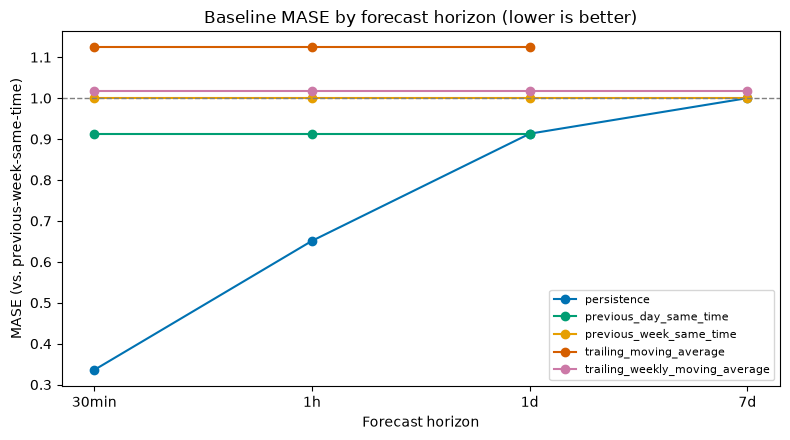

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {
    "persistence": "#0072B2",
    "previous_day_same_time": "#009E73",
    "previous_week_same_time": "#E69F00",
    "trailing_moving_average": "#D55E00",
    "trailing_weekly_moving_average": "#CC79A7",
}  # Okabe-Ito colorblind-safe palette, consistent with notebooks 01/04

horizon_names = list(config.HORIZONS)
by_model = {}
for horizon_name in horizon_names:
    overall = all_results[horizon_name].groupby("model")["mase"].mean()
    for model_name, value in overall.items():
        by_model.setdefault(model_name, {})[horizon_name] = value

for model_name, values in by_model.items():
    xs = [h for h in horizon_names if h in values]
    ys = [values[h] for h in xs]
    ax.plot(xs, ys, marker="o", label=model_name, color=colors[model_name])

ax.axhline(1.0, color="grey", linestyle="--", linewidth=1)
ax.set_title("Baseline MASE by forecast horizon (lower is better)")
ax.set_xlabel("Forecast horizon")
ax.set_ylabel("MASE (vs. previous-week-same-time)")
ax.legend(fontsize=8)
fig.tight_layout()